In [76]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import preprocessing
import sys
import matplotlib.pyplot as plt
import timeit

import time
# from time import time

import seaborn as sns
sns.set(style="darkgrid")

from sklearn.model_selection import train_test_split
import numpy.random as nr

import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import SGDClassifier, Perceptron
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
%matplotlib inline

In [77]:
# pca = PCA(random_state= '42')
# pca.fit(num_df)
# plt.plot(pca.explained_variance_ratio_)
nr.seed = 42

https://github.com/adomakor412/MachineLearning_DataMining/blob/master/HW/HW2/hw2_problem4.ipynb

In [78]:
#pd.read_csv?

In [79]:
data = pd.read_csv("dataDropped_from_162by127_to_157rowsby84columns.csv", sep=";")
data#.head()

,Unnamed: 0,1,2,3,4,5,6,7,8,15,...,118,119,120,121,122,123,124,125,126,127
0,4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
1,5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
2,6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
3,7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
4,8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
153,157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
154,158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
155,159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [80]:
#data.loc[1]
#data.iloc[1]
#data.loc?

In [81]:
data.columns

Index(['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '15', '16', '22',
       '23', '25', '26', '28', '29', '30', '32', '33', '34', '35', '44', '45',
       '46', '47', '48', '49', '55', '60', '61', '62', '65', '66', '67', '68',
       '69', '70', '71', '72', '75', '76', '79', '82', '83', '85', '86', '87',
       '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '100',
       '101', '102', '103', '104', '105', '106', '107', '108', '110', '111',
       '112', '113', '114', '115', '117', '118', '119', '120', '121', '122',
       '123', '124', '125', '126', '127'],
      dtype='object')

In [82]:
dfexp = data[data.columns[1:]]
dfexp 

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
0,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
1,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
2,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
3,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
4,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
153,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
154,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
155,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [83]:
dfexp.index

RangeIndex(start=0, stop=157, step=1)

In [84]:
dfexp.index = range(4, 161)

In [85]:
dfexp

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [86]:
df_Target = dfexp[dfexp['97']/2 >= dfexp['124']]
df_Target

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
11,7.0,45.0,3.0,147.0,1.0,585.0,75.0,800.0,277821.0,420.5,...,44.5,40.5,42.1,56.88,468.65,525.53,284.40,1848.0,284.40,3118.0
12,8.0,46.0,44.0,46.0,1.0,1450.0,150.0,1450.0,830000.0,550.1,...,43.3,39.3,40.9,218.12,2002.57,2220.69,1090.62,2036.0,1090.62,3103.0
30,26.0,248.0,14.0,61.0,1.0,400.0,80.0,500.0,104000.0,250.0,...,29.0,25.0,26.6,32.21,146.18,178.39,161.04,1108.0,161.04,2074.0
31,27.0,249.0,14.0,62.0,1.0,400.0,80.0,500.0,104000.0,250.0,...,29.0,25.0,26.6,32.21,146.18,178.39,161.04,1108.0,161.04,2167.0
83,82.0,485.0,19.0,39.0,1.0,300.0,50.0,350.0,41250.0,127.7,...,23.8,19.8,21.4,11.51,48.41,59.93,57.56,1041.0,57.56,1704.0
84,80.0,490.0,20.0,117.0,1.0,1500.0,100.0,900.0,362500.0,291.7,...,24.2,20.2,21.8,64.01,1020.61,1084.63,320.07,3389.0,320.07,2500.0
96,94.0,504.0,22.0,65.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,25.0,21.0,22.6,89.07,453.60,542.66,445.33,1219.0,445.33,1518.0
97,95.0,505.0,22.0,66.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,25.0,21.0,22.6,89.07,453.60,542.66,445.33,1219.0,445.33,1545.0
100,98.0,508.0,22.0,69.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,50.0,46.0,47.6,129.26,680.39,809.65,646.29,1253.0,646.29,1827.0
101,99.0,509.0,22.0,70.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,50.0,46.0,47.6,129.26,680.39,809.65,646.29,1253.0,646.29,1917.0


In [87]:
dfexp.index

RangeIndex(start=4, stop=161, step=1)

In [88]:
df_Target.index

Index([ 11,  12,  30,  31,  83,  84,  96,  97, 100, 101, 102, 128, 129, 130,
       131, 134, 135, 147, 148, 149],
      dtype='int64')

In [89]:
df_Target.index.to_list

<bound method IndexOpsMixin.tolist of Index([ 11,  12,  30,  31,  83,  84,  96,  97, 100, 101, 102, 128, 129, 130,
       131, 134, 135, 147, 148, 149],
      dtype='int64')>

In [90]:
listTargetIndex = list(df_Target.index)
listTargetIndex

[11,
 12,
 30,
 31,
 83,
 84,
 96,
 97,
 100,
 101,
 102,
 128,
 129,
 130,
 131,
 134,
 135,
 147,
 148,
 149]

In [91]:
dfexp['Target'] = 0

In [92]:
for i in listTargetIndex:
    dfexp['Target'].iloc[i] = 1
#Try using conditional indices]

In [93]:
dfexp.iloc[listTargetIndex]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
15,11.0,64.0,4.0,29.0,1.0,240.0,240.0,950.0,228000.0,475.0,...,22.7,24.3,176.75,140.42,317.17,883.75,0.359,317.17,1165.0,1
16,12.0,65.0,4.0,30.0,1.0,240.0,240.0,1250.0,300000.0,625.0,...,21.8,23.4,231.28,187.23,418.51,1156.42,0.362,418.51,1129.0,1
34,30.0,264.0,15.0,18.0,0.0,304.8,304.8,609.6,185806.0,304.8,...,51.9,53.5,199.42,122.65,322.06,997.08,0.323,322.06,1206.0,1
35,33.0,359.0,17.0,75.0,1.0,250.0,250.0,350.0,87500.0,175.0,...,57.6,59.2,93.28,63.69,156.97,466.41,0.337,156.97,1454.0,1
87,85.0,493.0,21.0,137.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,139.42,177.55,190.64,0.931,177.55,1549.0,1
88,86.0,494.0,21.0,138.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,82.66,120.79,190.64,0.634,120.79,1924.0,1
100,98.0,508.0,22.0,69.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1827.0,1
101,99.0,509.0,22.0,70.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1917.0,1
104,102.0,512.0,24.0,20.0,1.0,700.0,120.0,600.0,159600.0,261.1,...,22.6,24.2,52.95,219.52,272.47,264.73,1029.000,264.73,1643.0,1
105,103.0,523.0,25.0,72.0,1.0,650.0,86.3,490.0,90550.0,168.0,...,36.1,37.7,39.60,57.65,97.25,198.02,0.491,97.25,1296.0,1


In [94]:
dfexp

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000,0
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000,0
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000,0
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000,0
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000,0
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867,0
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000,0
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000,0


In [95]:
dfexp[dfexp['Target']==1]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
15,11.0,64.0,4.0,29.0,1.0,240.0,240.0,950.0,228000.0,475.0,...,22.7,24.3,176.75,140.42,317.17,883.75,0.359,317.17,1165.0,1
16,12.0,65.0,4.0,30.0,1.0,240.0,240.0,1250.0,300000.0,625.0,...,21.8,23.4,231.28,187.23,418.51,1156.42,0.362,418.51,1129.0,1
34,30.0,264.0,15.0,18.0,0.0,304.8,304.8,609.6,185806.0,304.8,...,51.9,53.5,199.42,122.65,322.06,997.08,0.323,322.06,1206.0,1
35,33.0,359.0,17.0,75.0,1.0,250.0,250.0,350.0,87500.0,175.0,...,57.6,59.2,93.28,63.69,156.97,466.41,0.337,156.97,1454.0,1
87,85.0,493.0,21.0,137.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,139.42,177.55,190.64,0.931,177.55,1549.0,1
88,86.0,494.0,21.0,138.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,82.66,120.79,190.64,0.634,120.79,1924.0,1
100,98.0,508.0,22.0,69.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1827.0,1
101,99.0,509.0,22.0,70.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1917.0,1
104,102.0,512.0,24.0,20.0,1.0,700.0,120.0,600.0,159600.0,261.1,...,22.6,24.2,52.95,219.52,272.47,264.73,1029.000,264.73,1643.0,1
105,103.0,523.0,25.0,72.0,1.0,650.0,86.3,490.0,90550.0,168.0,...,36.1,37.7,39.60,57.65,97.25,198.02,0.491,97.25,1296.0,1


In [96]:
scaler = StandardScaler()
standardized_features = scaler.fit_transform(dfexp)
standardized_features

array([[-1.72105355, -2.14908591, -1.9688346 , ..., -0.82491838,
        -0.56068325, -0.38208036],
       [-1.69898876, -2.13429062, -1.9688346 , ..., -0.74361089,
        -0.64454978, -0.38208036],
       [-1.67692397, -2.12935886, -1.9688346 , ..., -0.68477363,
        -0.80205522, -0.38208036],
       ...,
       [-1.03704509,  1.80125534, -0.52398724, ...,  0.98256227,
         0.25139022, -0.38208036],
       [-1.0149803 ,  1.8061871 , -0.52398724, ...,  0.57938694,
         0.4784435 , -0.38208036],
       [ 1.52247045,  2.06757048,  1.73358676, ...,  0.6372716 ,
        -3.1892137 , -0.38208036]])

In [97]:
df_standard = pd.DataFrame(standardized_features)
df_standard.index = dfexp.index
df_standard.columns = dfexp.columns

In [98]:
df_standard

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,-1.721054,-2.149086,-1.968835,-0.354802,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,-0.332096,-0.332096,-0.725716,-0.498787,-0.681524,-0.725763,-0.407708,-0.824918,-0.560683,-0.38208
5,-1.698989,-2.134291,-1.968835,-0.444502,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.012806,2.012806,-0.566462,-0.498787,-0.629092,-0.566421,-0.407836,-0.743611,-0.644550,-0.38208
6,-1.676924,-2.129359,-1.968835,-0.422077,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,1.677249,1.677249,-0.586341,-0.448635,-0.591150,-0.586388,-0.407751,-0.684774,-0.802055,-0.38208
7,-1.654859,-2.124427,-1.968835,-0.399652,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.216537,2.216537,-0.554820,-0.405199,-0.542187,-0.554779,-0.407712,-0.608846,-0.830693,-0.38208
8,-1.632794,-2.119495,-1.968835,-0.377227,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.036774,2.036774,-0.565034,-0.498787,-0.628658,-0.565015,-0.407837,-0.742938,-0.859330,-0.38208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1.235628,1.786460,1.191769,-1.677882,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,-0.076434,-0.076434,-0.380409,-0.464959,-0.537887,-0.380455,-0.407872,-0.602177,0.050929,-0.38208
157,1.257693,1.796324,1.191769,-1.655457,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,0.023434,0.023434,-0.363275,-0.015704,-0.133461,-0.363300,-0.407435,0.024972,-3.189455,-0.38208
158,-1.037045,1.801255,-0.523987,-1.139680,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.759532,-0.759532,0.064405,0.521440,0.484055,0.064425,-0.407366,0.982562,0.251390,-0.38208
159,-1.014980,1.806187,-0.523987,-1.094830,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.735563,-0.735563,0.075058,0.224596,0.224061,0.075057,-0.407548,0.579387,0.478444,-0.38208


In [99]:
df_standard.Target.unique

<bound method Series.unique of 4     -0.38208
5     -0.38208
6     -0.38208
7     -0.38208
8     -0.38208
        ...   
156   -0.38208
157   -0.38208
158   -0.38208
159   -0.38208
160   -0.38208
Name: Target, Length: 157, dtype: float64>

In [100]:
df_standard['Target'].unique

<bound method Series.unique of 4     -0.38208
5     -0.38208
6     -0.38208
7     -0.38208
8     -0.38208
        ...   
156   -0.38208
157   -0.38208
158   -0.38208
159   -0.38208
160   -0.38208
Name: Target, Length: 157, dtype: float64>

In [101]:
df_standard['Target'].unique()

array([-0.38208036,  2.61725047])

# How well can we classify those that fail below ACI shear from those that do not?

In [102]:
dfexp[dfexp.columns[:-1]]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [103]:
scaler = StandardScaler()
standardized_features = scaler.fit_transform(dfexp[dfexp.columns[:-1]])

X=standardized_features
y= dfexp['Target']

In [104]:
#train_test_split?

training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


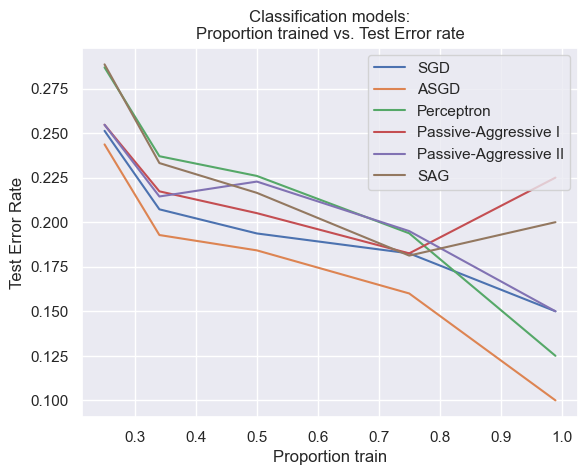

0.6068389415740967 seconds


In [105]:
start = time.time()
#heldout = [0.95, 0.90, 0.75, 0.50, 0.01] #works well for balanced dataset
heldout = [0.75, 0.66, 0.50, 0.25, 0.01]
rounds = 20

classifiers = [
    ("SGD", SGDClassifier(max_iter=100)),
    ("ASGD", SGDClassifier(average=True)),
    ("Perceptron", Perceptron()),
    ("Passive-Aggressive I", PassiveAggressiveClassifier(loss='hinge',
                                                         C=1.0, tol=1e-4)),
    ("Passive-Aggressive II", PassiveAggressiveClassifier(loss='squared_hinge',
                                                          C=1.0, tol=1e-4)),
    ("SAG", LogisticRegression(solver='sag', tol=1e-1, C=1.e4 / X.shape[0]))
]

xx = 1. - np.array(heldout)

for name, clf in classifiers:
    print("training %s" % name)
    rng = np.random.RandomState(42)
    yy = []
    for i in heldout:
        yy_ = []
        for r in range(rounds):
            X_train, X_test, y_train, y_test = \
                train_test_split(X, y, test_size=i, random_state=rng)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            yy_.append(1 - np.mean(y_pred == np.array(y_test)))
        yy.append(np.mean(yy_))
    plt.plot(xx, yy, label=name)
plt.title('Classification models:\nProportion trained vs. Test Error rate')
plt.legend(loc="upper right")
plt.xlabel("Proportion train")
plt.ylabel("Test Error Rate")
plt.show()
end = time.time()
print(end-start, 'seconds')

In [106]:
plt.savefig("Full_data_TestErrorRate")

<Figure size 640x480 with 0 Axes>

## Consider Cross Validation now

KFold(n_splits=5, random_state=None, shuffle=False)
TRAIN: [ 32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49
  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156] TEST: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


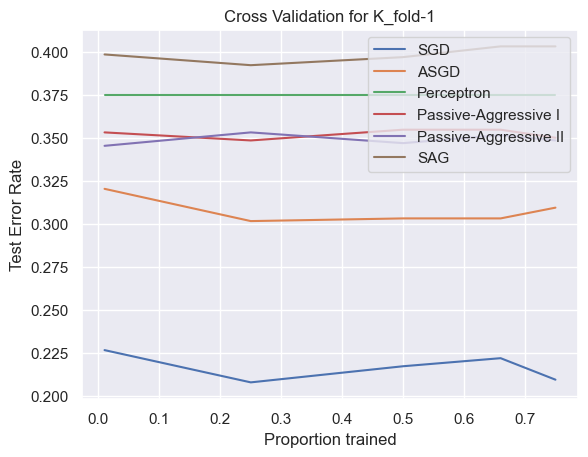

TRAIN: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  64  65  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156] TEST: [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55
 56 57 58 59 60 61 62 63]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


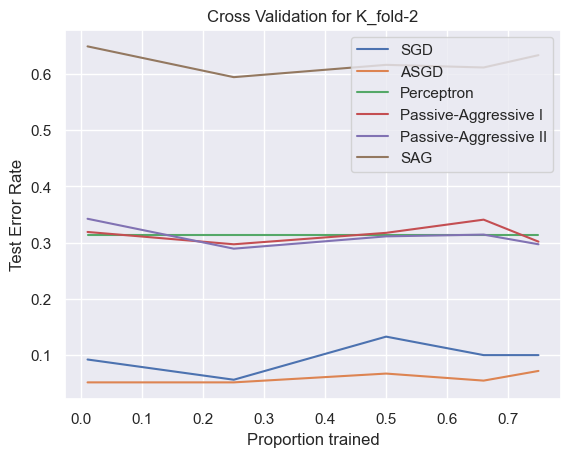

TRAIN: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156] TEST: [64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87
 88 89 90 91 92 93 94]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


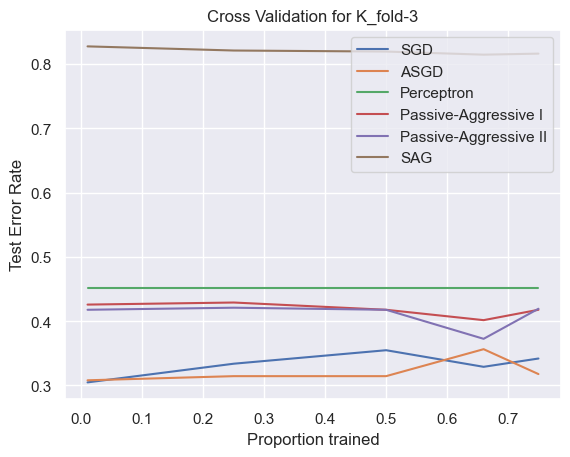

TRAIN: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156] TEST: [ 95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 113 114 115 116 117 118 119 120 121 122 123 124 125]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


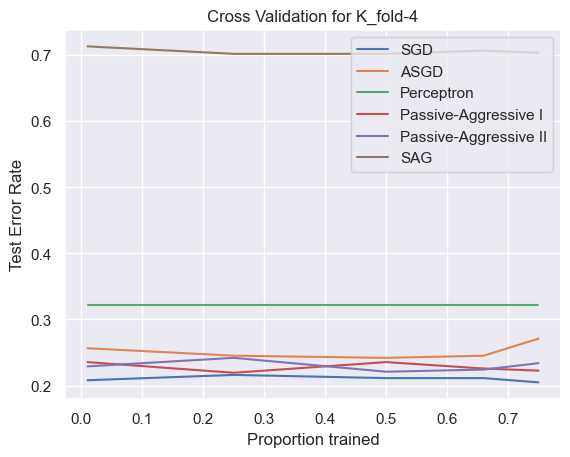

TRAIN: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125] TEST: [126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


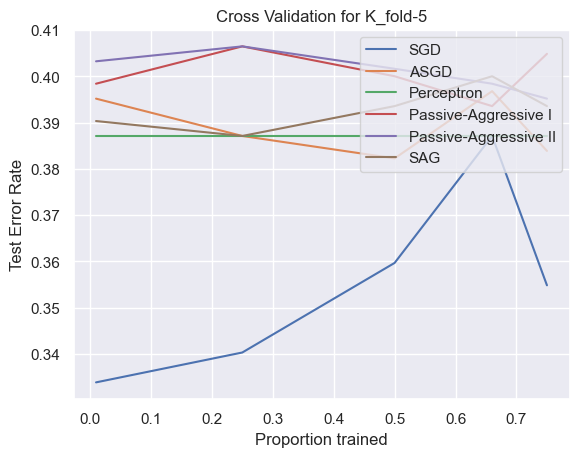

In [107]:
start = time.time()

kf = KFold(n_splits=5)
kf.get_n_splits(X)
print(kf)

xx = ['K_fold-1','K_fold-2','K_fold-3','K_fold-4','K_fold-5']
rounds = 20
count = 0
for train_index, test_index in kf.split(X):
     print("TRAIN:", train_index, "TEST:", test_index)
     X_train, X_test = np.array(X)[np.array(train_index)], np.array(X)[np.array(test_index)]
     y_train, y_test = np.array(y)[np.array(train_index)], np.array(y)[np.array(test_index)]
        
     classifiers = [
        ("SGD", SGDClassifier(max_iter=100)),
        ("ASGD", SGDClassifier(average=True)),
        ("Perceptron", Perceptron()),
        ("Passive-Aggressive I", PassiveAggressiveClassifier(loss='hinge',
                                                             C=1.0, tol=1e-4)),
        ("Passive-Aggressive II", PassiveAggressiveClassifier(loss='squared_hinge',
                                                              C=1.0, tol=1e-4)),
        ("SAG", LogisticRegression(solver='sag', tol=1e-1, C=1.e4 / X.shape[0]))
     ]
     #count+=1

     for name, clf in classifiers:
         print("training %s" % name)
         rng = np.random.RandomState(42)
         yy = []
         for i in heldout:
             yy_ = []
             for r in range(rounds):
                 clf.fit(X_train, y_train)
                 y_pred = clf.predict(X_test)
                 yy_.append(1 - np.mean(y_pred == np.array(y_test)))
             yy.append(np.mean(yy_))
             #plt.title(f"Cross Validation Test Error Rate: {i}% trained")
         #plt.plot(xx, yy, label=name)
         plt.plot(heldout, yy, label=name)
     plt.title(f"Cross Validation for {xx[count]}")
     plt.legend(loc="upper right")
     plt.xlabel("Proportion trained")#
     #plt.xlabel("Train-Test Index")
     plt.ylabel("Test Error Rate")
     plt.show()
     #plt.savefig(f"CrossValidationTestErrorRate_{i}_percent_trained.png")
     #plt.savefig(f"CrossValidation_{xx[count]}.png")
     count+=1
end = time.time()
